In [1]:
import argparse
import json
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from ndn_pipeline import (
    ROOT_DIR, LOG_ROOT, MODEL_DIR,
    FEATURE_COLS, RATE_COLS,
    MODEL_PATH, THRESHOLD_PATH, CLIP_BOUNDS_PATH,
    load_artifacts, load_raw_logs,
    clean_logs, engineer_features_df,
    logger,
)

# ── Default scenarios to test ─────────────────────────────────────────────────
DEFAULT_SCENARIOS = ["new_cp_2", "new_ifa_1"]

# Human-readable labels for each scenario folder
SCENARIO_LABELS = {
    "new_cp_2"  : "Cache Pollution (CP)",
    "new_ifa_1" : "Interest Flooding (IFA)",
}

In [2]:
def load_and_summarise() -> tuple:
    """Load model artifacts and print a summary of what was trained."""
    print(f"\n{'='*60}")
    print("  Model artifacts")
    print(f"{'='*60}")

    for p in [MODEL_PATH, THRESHOLD_PATH, CLIP_BOUNDS_PATH]:
        if not p.exists():
            print(f"\n  ERROR: missing artifact → {p}")
            print("  Run ndn_pipeline.py first to train the model.")
            sys.exit(1)

    pipeline, threshold, clip_bounds = load_artifacts()
    meta = json.loads(THRESHOLD_PATH.read_text())

    print(f"  Trained at        : {meta.get('trained_at', 'unknown')}")
    print(f"  Training nodes    : {meta.get('trained_on_nodes', [])}")
    print(f"  Training samples  : {meta.get('n_training_samples', '?'):,}")
    print(f"  Threshold         : {threshold:+.6f}  "
          f"(p{meta.get('anomaly_percentile', '?')} of training scores)")
    if "score_min" in meta:
        print(f"  Training score    : "
              f"min={meta['score_min']:+.6f}  "
              f"max={meta['score_max']:+.6f}  "
              f"mean={meta['score_mean']:+.6f}")

    return pipeline, threshold, clip_bounds, meta


# %% ── Cell 3 · Load & Engineer Features for One Scenario ────────────────────

def load_scenario(scenario: str, clip_bounds: dict) -> pd.DataFrame:
    """
    Load raw logs for one scenario, clean with NO warmup, engineer features,
    and apply training-time clip bounds to rate features.
    """
    label = SCENARIO_LABELS.get(scenario, scenario)
    print(f"\n{'='*60}")
    print(f"  Loading: {label}  [{scenario}]")
    print(f"{'='*60}")

    raw   = load_raw_logs([scenario], log_root=LOG_ROOT)
    clean = clean_logs(raw, warmup_seconds=0)   # no warmup — attack-time logs
    feats = engineer_features_df(clean)

    # Apply training clip bounds so features match the model's training space
    for col in RATE_COLS:
        if col in clip_bounds:
            feats[col] = feats[col].clip(
                clip_bounds[col]["lo"], clip_bounds[col]["hi"]
            )

    feats["scenario"] = scenario
    feats["scenario_label"] = label
    print(f"  Feature rows      : {len(feats):,}")
    print(f"  Nodes             : {sorted(feats['node'].unique())}")
    return feats


# %% ── Cell 4 · Score One Scenario ───────────────────────────────────────────

def score_scenario(
    feats: pd.DataFrame,
    pipeline,
    threshold: float,
    meta: dict,
) -> pd.DataFrame:
    """
    Run inference on a feature DataFrame. Adds columns:
      anomaly_score, normalized_score, is_anomaly
    """
    X      = feats[FEATURE_COLS].values
    scores = pipeline.decision_function(X)

    s_min  = meta.get("score_min", -0.5)
    s_max  = meta.get("score_max",  0.5)
    span   = max(s_max - s_min, 1e-9)
    norm   = np.clip((scores - s_min) / span * 100, 0, 100)

    result = feats.copy()
    result["anomaly_score"]    = scores
    result["normalized_score"] = norm
    result["is_anomaly"]       = scores < threshold
    return result


# %% ── Cell 5 · Per-Scenario Summary ─────────────────────────────────────────

def scenario_summary(result: pd.DataFrame, threshold: float) -> None:
    """Print headline detection stats for one scenario."""
    label   = result["scenario_label"].iloc[0]
    n       = len(result)
    n_anom  = result["is_anomaly"].sum()
    pct     = 100.0 * n_anom / n if n else 0
    scores  = result["anomaly_score"]

    print(f"\n  {label}")
    print(f"  {'─'*40}")
    print(f"  Total samples     : {n:,}")
    print(f"  Anomalies flagged : {n_anom:,}  ({pct:.1f}%)")
    print(f"  Score range       : [{scores.min():+.6f}, {scores.max():+.6f}]")
    print(f"  Score mean        : {scores.mean():+.6f}")
    print(f"  Threshold         : {threshold:+.6f}")


# %% ── Cell 6 · Per-Node Breakdown ───────────────────────────────────────────

def node_breakdown(result: pd.DataFrame) -> pd.DataFrame:
    """Print per-node stats and return summary DataFrame."""
    label = result["scenario_label"].iloc[0]
    print(f"\n  Per-node — {label}")
    print(f"  {'node':<12} {'samples':>8} {'anomalies':>10} {'anom%':>7} "
          f"{'score_mean':>12} {'score_min':>12}")
    print(f"  {'─'*12} {'─'*8} {'─'*10} {'─'*7} {'─'*12} {'─'*12}")

    rows = []
    for node, grp in result.groupby("node"):
        n      = len(grp)
        n_anom = grp["is_anomaly"].sum()
        rows.append({
            "node"       : node,
            "samples"    : n,
            "anomalies"  : n_anom,
            "anom_pct"   : round(100.0 * n_anom / n, 1) if n else 0,
            "score_mean" : round(grp["anomaly_score"].mean(), 6),
            "score_min"  : round(grp["anomaly_score"].min(), 6),
        })
        print(f"  {node:<12} {n:>8} {n_anom:>10} "
              f"{100.0*n_anom/n:>6.1f}% "
              f"{grp['anomaly_score'].mean():>+12.6f} "
              f"{grp['anomaly_score'].min():>+12.6f}")

    return pd.DataFrame(rows)


# %% ── Cell 7 · Distribution Drift ───────────────────────────────────────────

def drift_report(feats: pd.DataFrame, pipeline) -> pd.DataFrame:
    """
    Compare per-feature means of this scenario against the training scaler.
    Z > 3 → DRIFTED (feature shifted by more than 3 training standard deviations).
    """
    label  = feats["scenario_label"].iloc[0]
    scaler = pipeline.named_steps["scaler"]

    print(f"\n  Drift report — {label}")
    print(f"  {'feature':<22} {'test_μ':>10} {'train_μ':>10} "
          f"{'train_σ':>10} {'z':>8}  status")
    print(f"  {'─'*22} {'─'*10} {'─'*10} {'─'*10} {'─'*8}  {'─'*8}")

    rows = []
    for j, col in enumerate(FEATURE_COLS):
        mu_i   = feats[col].mean()
        mu_t   = scaler.mean_[j]
        si_t   = scaler.scale_[j]
        z      = abs(mu_i - mu_t) / (si_t + 1e-12)
        status = "DRIFTED" if z > 3 else ("slight" if z > 1.5 else "ok")
        print(f"  {col:<22} {mu_i:>10.4f} {mu_t:>10.4f} "
              f"{si_t:>10.4f} {z:>8.3f}  {status}")
        rows.append(dict(feature=col, test_mean=round(mu_i,5),
                         train_mean=round(mu_t,5), train_std=round(si_t,5),
                         z_score=round(z,3), status=status))

    drift_df = pd.DataFrame(rows)
    drifted  = drift_df[drift_df["status"] == "DRIFTED"]["feature"].tolist()
    if drifted:
        print(f"\n  *** Drifted: {drifted}")
    else:
        print(f"\n  All features within 3σ of training.")
    return drift_df


# %% ── Cell 8 · Score Distribution Plots ─────────────────────────────────────

def plot_scores(results: Dict[str, pd.DataFrame], threshold: float) -> None:
    """
    One figure per scenario: score histogram (normal vs anomaly rows) +
    per-node box plot.  Silently skips if matplotlib is unavailable.
    """
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        logger.info("matplotlib not available — skipping plots")
        return

    for scenario, result in results.items():
        label  = SCENARIO_LABELS.get(scenario, scenario)
        scores = result["anomaly_score"]
        nodes  = sorted(result["node"].unique())

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Score distribution — {label}", fontweight="bold")

        # Histogram: normal vs anomaly
        normal = scores[~result["is_anomaly"]]
        anom   = scores[result["is_anomaly"]]
        ax1.hist(normal.values, bins=40, color="steelblue", alpha=0.75,
                 label=f"normal ({len(normal)})", edgecolor="none")
        ax1.hist(anom.values,   bins=max(10, len(anom)//3 + 1),
                 color="tomato", alpha=0.85,
                 label=f"anomaly ({len(anom)})", edgecolor="none")
        ax1.axvline(threshold, color="red", linewidth=2, linestyle="--",
                    label=f"threshold={threshold:.3e}")
        ax1.set_xlabel("decision_function score", fontweight="bold")
        ax1.set_ylabel("count", fontweight="bold")
        ax1.legend(fontsize=9)

        # Box plot per node
        node_score_lists = [
            result[result["node"] == n]["anomaly_score"].values
            for n in nodes
        ]
        ax2.boxplot(node_score_lists, labels=nodes, vert=True)
        ax2.axhline(threshold, color="red", linewidth=1.5, linestyle="--",
                    label="threshold")
        ax2.set_xlabel("node", fontweight="bold")
        ax2.set_ylabel("anomaly_score", fontweight="bold")
        ax2.legend(fontsize=9)

        plt.tight_layout()
        plt.show()


# %% ── Cell 9 · Anomaly Deep-Dive ────────────────────────────────────────────

def anomaly_deep_dive(result: pd.DataFrame, pipeline, top_n: int = 5) -> None:
    """
    Show the top_n lowest-scoring (most anomalous) rows with per-feature
    z-scores relative to the training scaler, so you can see what drove each alert.
    """
    label    = result["scenario_label"].iloc[0]
    anomalies = result[result["is_anomaly"]]

    if anomalies.empty:
        print(f"\n  [{label}] No anomalies detected.")
        return

    print(f"\n  Deep-dive — {label}  "
          f"(top {min(top_n, len(anomalies))} most anomalous rows)")

    scaler   = pipeline.named_steps["scaler"]
    top_rows = anomalies.nsmallest(top_n, "anomaly_score")

    for _, row in top_rows.iterrows():
        print(f"\n  node={row['node']}  ts={row['timestamp']}  "
              f"score={row['anomaly_score']:+.6f}  "
              f"norm={row['normalized_score']:.1f}%")
        print(f"  {'feature':<22} {'value':>12} {'z_train':>9}  flag")
        print(f"  {'─'*22} {'─'*12} {'─'*9}  {'─'*8}")
        for j, col in enumerate(FEATURE_COLS):
            val = row[col]
            z   = (val - scaler.mean_[j]) / (scaler.scale_[j] + 1e-12)
            flag = "HIGH ^^" if z > 2 else ("LOW vv" if z < -2 else "")
            print(f"  {col:<22} {val:>12.5f} {z:>+9.3f}  {flag}")


# %% ── Cell 10 · Cross-Scenario Comparison ───────────────────────────────────

def cross_scenario_comparison(
    results: Dict[str, pd.DataFrame],
    threshold: float,
) -> None:
    """
    Side-by-side detection summary across all tested scenarios, plus a
    feature-mean comparison table so you can see what distinguishes CP from IFA.
    """
    print(f"\n{'='*60}")
    print("  Cross-scenario comparison")
    print(f"{'='*60}")

    # Detection headline table
    print(f"\n  {'scenario':<28} {'samples':>8} {'anomalies':>10} "
          f"{'detect%':>8} {'score_mean':>12}")
    print(f"  {'─'*28} {'─'*8} {'─'*10} {'─'*8} {'─'*12}")
    for scenario, result in results.items():
        label  = SCENARIO_LABELS.get(scenario, scenario)
        n      = len(result)
        n_anom = result["is_anomaly"].sum()
        print(f"  {label:<28} {n:>8} {n_anom:>10} "
              f"{100.0*n_anom/n:>7.1f}% "
              f"{result['anomaly_score'].mean():>+12.6f}")

    # Feature-mean comparison
    print(f"\n  Feature means per scenario")
    print(f"  {'feature':<22}", end="")
    for scenario in results:
        print(f"  {SCENARIO_LABELS.get(scenario, scenario)[:16]:>16}", end="")
    print()
    print(f"  {'─'*22}", end="")
    for _ in results:
        print(f"  {'─'*16}", end="")
    print()

    for col in FEATURE_COLS:
        print(f"  {col:<22}", end="")
        for result in results.values():
            print(f"  {result[col].mean():>16.4f}", end="")
        print()


# %% ── Cell 11 · Export Results ───────────────────────────────────────────────

def export_results(
    results: Dict[str, pd.DataFrame],
    out_dir: Optional[Path] = None,
) -> None:
    """Save per-scenario scored CSVs to out_dir (defaults to ROOT_DIR/Results)."""
    if out_dir is None:
        out_dir = ROOT_DIR / "Results"
    out_dir.mkdir(exist_ok=True)

    export_cols = (["timestamp", "node", "scenario", "anomaly_score",
                    "normalized_score", "is_anomaly"] + FEATURE_COLS)

    for scenario, result in results.items():
        cols    = [c for c in export_cols if c in result.columns]
        outfile = out_dir / f"{scenario}_scored.csv"
        result[cols].to_csv(outfile, index=False)
        print(f"  Saved → {outfile}")


# %% ── Cell 12 · Main ─────────────────────────────────────────────────────────

def parse_args():
    p = argparse.ArgumentParser(
        description="Score NDN attack logs against the pre-trained model."
    )
    p.add_argument(
        "--scenarios", nargs="+", default=DEFAULT_SCENARIOS,
        help=f"Scenario folder names under Logs/ (default: {DEFAULT_SCENARIOS})",
    )
    p.add_argument(
        "--top-n", type=int, default=5,
        help="Rows to show in the anomaly deep-dive per scenario (default: 5)",
    )
    p.add_argument(
        "--no-plots", action="store_true",
        help="Suppress matplotlib plots",
    )
    p.add_argument(
        "--out-dir", type=Path, default=None,
        help="Directory for scored CSV exports (default: Results/)",
    )
    p.add_argument(
        "--no-export", action="store_true",
        help="Skip CSV export",
    )
    return p.parse_args()

INFO  Artifacts loaded from /Users/darshan/college/6th_sem/Minor/Models
INFO  Threshold : 0.000000e+00
INFO  Found 12 JSONL files across 1 scenario(s)



  Model artifacts
  Trained at        : 2026-05-12T09:38:34.590922
  Training nodes    : ['bottleneck', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']
  Training samples  : 126,423
  Threshold         : +0.000000  (p1 of training scores)
  Training score    : min=-0.146181  max=+0.283235  mean=+0.188531

  Loading: Cache Pollution (CP)  [new_cp_2]


Parsing logs: 100%|█| 12/12 [00:0
INFO  Raw records loaded: 696
INFO    Duplicates removed   : 0
INFO    Clean records        : 696  (from 696 raw)
INFO    Nodes present        : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']
INFO    Feature rows after diff-drop: 684  (dropped 12)
INFO  Found 12 JSONL files across 1 scenario(s)


  Feature rows      : 684
  Nodes             : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']

  Loading: Interest Flooding (IFA)  [new_ifa_1]


Parsing logs: 100%|█| 12/12 [00:0
INFO  Raw records loaded: 719
INFO    Duplicates removed   : 0
INFO    Clean records        : 719  (from 719 raw)
INFO    Nodes present        : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']
INFO    Feature rows after diff-drop: 707  (dropped 12)


  Feature rows      : 707
  Nodes             : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']

  Detection results

  Cache Pollution (CP)
  ────────────────────────────────────────
  Total samples     : 684
  Anomalies flagged : 53  (7.7%)
  Score range       : [-0.091015, +0.182299]
  Score mean        : +0.088413
  Threshold         : +0.000000

  Interest Flooding (IFA)
  ────────────────────────────────────────
  Total samples     : 707
  Anomalies flagged : 23  (3.3%)
  Score range       : [-0.036905, +0.181479]
  Score mean        : +0.129741
  Threshold         : +0.000000

  Per-node breakdown

  Per-node — Cache Pollution (CP)
  node          samples  anomalies   anom%   score_mean    score_min
  ──────────── ──────── ────────── ─────── ──────────── ────────────
  c1                 57         47   82.5%    -0.046691    -0.091015
  c2                 57          1    1.8%    +0.138990    -0.027480
  c3                 57          1    1.8%    +0.143

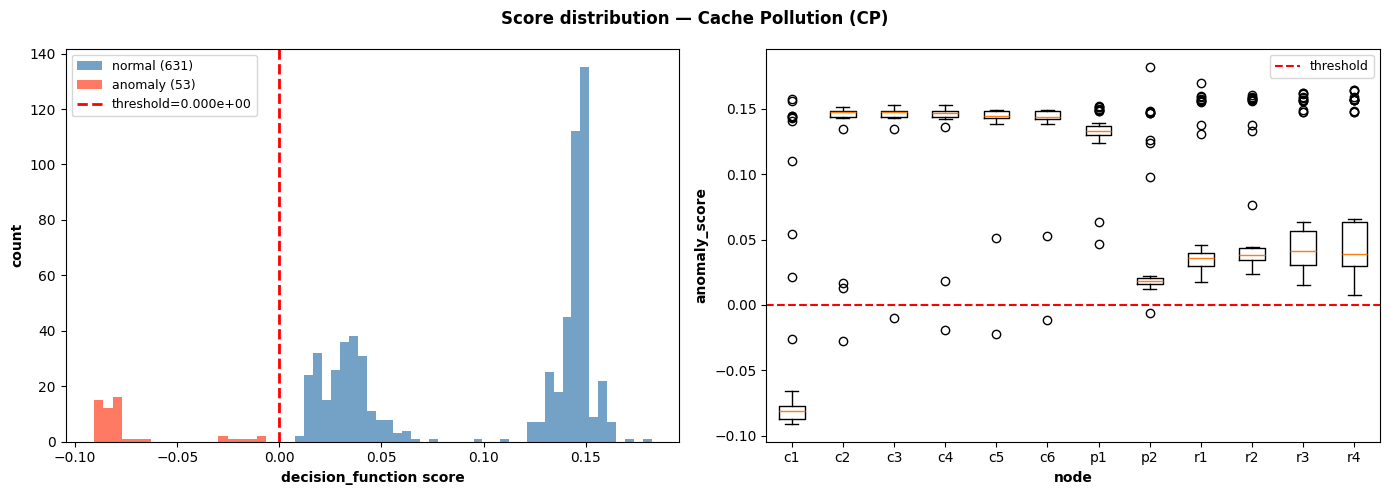

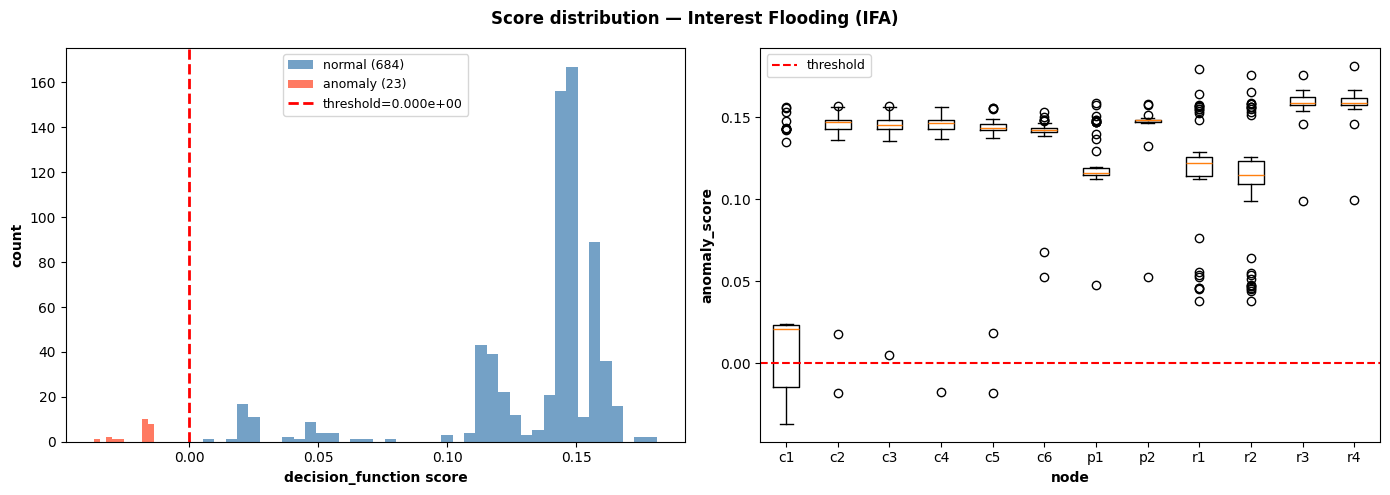


  Anomaly deep-dive

  Deep-dive — Cache Pollution (CP)  (top 5 most anomalous rows)

  node=c1  ts=2026-05-12 10:30:48.445138  score=-0.091015  norm=12.8%
  feature                       value   z_train  flag
  ────────────────────── ──────────── ─────────  ────────
  pit_size                   13.00000   +57.396  HIGH ^^
  pit_growth_rate             0.00000    +0.000  
  cs_size                   267.00000    -0.685  
  cache_hit_ratio             0.11079    +7.826  HIGH ^^
  satisfaction_ratio          0.89109    +0.279  
  unsatisfied_ratio           0.10891   +39.873  HIGH ^^
  in_interests_rate          18.94837    +2.893  HIGH ^^
  out_interests_rate         11.81763    +2.880  HIGH ^^
  in_data_rate               11.49386    +2.760  HIGH ^^
  nack_rate                   0.00000    +0.000  

  node=c1  ts=2026-05-12 10:32:58.889140  score=-0.091015  norm=12.8%
  feature                       value   z_train  flag
  ────────────────────── ──────────── ─────────  ────────
  pit_

In [3]:

def main():
    # ── Configuration — tweak these ──────────────────────────────────────────
    SCENARIOS  = ["new_cp_2", "new_ifa_1"]  # scenario folders under Logs/
    SHOW_PLOTS = True                        # set False to suppress matplotlib
    EXPORT_CSV = True                        # save scored CSVs to Results/
    OUT_DIR    = None                        # Path override; None → Results/
    TOP_N      = 5                           # rows shown in anomaly deep-dive
    # ─────────────────────────────────────────────────────────────────────────

    # ── 1. Artifacts ────────────────────────────────────────────────────────
    pipeline, threshold, clip_bounds, meta = load_and_summarise()

    # ── 2. Load, engineer, and score each scenario ───────────────────────────
    results: Dict[str, pd.DataFrame] = {}

    for scenario in SCENARIOS:
        feats  = load_scenario(scenario, clip_bounds)
        result = score_scenario(feats, pipeline, threshold, meta)
        results[scenario] = result

    # ── 3. Per-scenario output ───────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("  Detection results")
    print(f"{'='*60}")

    for scenario, result in results.items():
        scenario_summary(result, threshold)

    print(f"\n{'='*60}")
    print("  Per-node breakdown")
    print(f"{'='*60}")
    for result in results.values():
        node_breakdown(result)

    # ── 4. Drift reports ─────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("  Distribution drift vs training")
    print(f"{'='*60}")
    for result in results.values():
        drift_report(result, pipeline)

    # ── 5. Plots ─────────────────────────────────────────────────────────────
    if SHOW_PLOTS:
        plot_scores(results, threshold)

    # ── 6. Deep-dive ─────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("  Anomaly deep-dive")
    print(f"{'='*60}")
    for result in results.values():
        anomaly_deep_dive(result, pipeline, top_n=TOP_N)

    # ── 7. Cross-scenario comparison ─────────────────────────────────────────
    if len(results) > 1:
        cross_scenario_comparison(results, threshold)

    # ── 8. Export ────────────────────────────────────────────────────────────
    if EXPORT_CSV:
        print(f"\n{'='*60}")
        print("  Exporting scored CSVs")
        print(f"{'='*60}")
        export_results(results, out_dir=OUT_DIR)

    print(f"\n{'='*60}")
    print("  Done.")
    print(f"{'='*60}\n")

    return results


if __name__ == "__main__":
    results = main()

In [4]:
print(1)

1
